In [2]:
class pinn_architecture(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer1 = nn.Linear(2, 20)
        self.layer2 = nn.Linear(20,20)
        self.layer3 = nn.Linear(20,20)
        self.layer4 = nn.Linear(20, 20)
        self.layer5 = nn.Linear(20,1)
        
    def forward(self, x, t):
        xt = torch.cat([x,t], dim = 1)
        out = torch.tanh(self.layer1(xt))
        out = torch.tanh(self.layer2(out))
        out = torch.tanh(self.layer3(out))
        out = torch.tanh(self.layer4(out))
        out = self.layer5(out)
        return out
        

In [3]:
def compute_loss(model, alpha, x_f, t_f, x_bc, t_bc, x_ic, t_ic):
    x_f.requires_grad_(True)
    t_f.requires_grad_(True)
    
    #get u values from model
    u_f = model(x_f,t_f)
    
    #compute x derivatives using autograd
    u_x = torch.autograd.grad(u_f, x_f, grad_outputs = torch.ones_like(u_f), create_graph = True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs = torch.ones_like(u_x), create_graph = True)[0]
    
    #compute t derivative the same way
    u_t = torch.autograd.grad(u_f, t_f, grad_outputs = torch.ones_like(u_f), create_graph = True)[0]
    
    #pde loss from pde residual
    pde_residual = u_t - alpha * u_xx
    pde_loss = torch.mean(pde_residual**2)
    
    #boundary condition loss 
    u_bc = model(x_bc, t_bc)
    bc_loss = torch.mean(u_bc**2)
    
    #initial conditions loss from start u(x,0) = sin(pi*x)
    u_ic = model(x_ic, t_ic)
    true_ic = torch.sin(torch.pi * x_ic)
    ic_loss = torch.mean((u_ic - true_ic)**2)
    
    #add the 3 for total loss
    total_loss = pde_loss + bc_loss + ic_loss
    
    return total_loss, pde_loss, bc_loss, ic_loss

In [4]:
def sample_points(N_f, N_bc, N_ic):
    x_f = torch.rand(N_f ,1)
    t_f = torch.rand(N_f, 1)
    
    x_bc_0 = torch.zeros(N_bc, 1)
    x_bc_1 = torch.ones(N_bc, 1)
    x_bc = torch.cat([x_bc_0, x_bc_1], dim = 0)
    
    t_bc = torch.cat([torch.rand(N_bc, 1), torch.rand(N_bc, 1)], dim=0)
    
    x_ic = torch.rand(N_ic, 1)
    t_ic = torch.zeros(N_ic, 1)
    
    return x_f, t_f, x_bc, t_bc, x_ic, t_ic


Iter 200 | Total: 7.9972e-02 | PDE: 2.9874e-03 | BC: 3.0077e-02 | IC: 4.6908e-02
Iter 400 | Total: 5.1853e-03 | PDE: 2.7870e-03 | BC: 7.5344e-04 | IC: 1.6449e-03
Iter 600 | Total: 9.0057e-04 | PDE: 7.5770e-04 | BC: 6.0984e-05 | IC: 8.1890e-05
Iter 800 | Total: 4.5946e-04 | PDE: 3.8622e-04 | BC: 2.5102e-05 | IC: 4.8140e-05
Iter 1000 | Total: 2.5710e-04 | PDE: 2.4118e-04 | BC: 7.7384e-06 | IC: 8.1778e-06
Iter 1200 | Total: 1.9074e-04 | PDE: 1.8011e-04 | BC: 5.8939e-06 | IC: 4.7357e-06
Iter 1400 | Total: 1.5288e-04 | PDE: 1.4368e-04 | BC: 5.8883e-06 | IC: 3.3071e-06
Iter 1600 | Total: 1.3099e-04 | PDE: 1.1771e-04 | BC: 8.2526e-06 | IC: 5.0203e-06
Iter 1800 | Total: 1.1999e-04 | PDE: 1.0004e-04 | BC: 8.9598e-06 | IC: 1.0992e-05
Iter 2000 | Total: 9.0522e-05 | PDE: 8.1913e-05 | BC: 6.8397e-06 | IC: 1.7696e-06
L-BFGS Iter 10 | Total: 8.7183e-05 | PDE: 7.7935e-05 | BC: 7.6389e-06 | IC: 1.6096e-06
L-BFGS Iter 20 | Total: 6.4017e-05 | PDE: 4.7005e-05 | BC: 1.1728e-05 | IC: 5.2849e-06
L-BFGS Ite

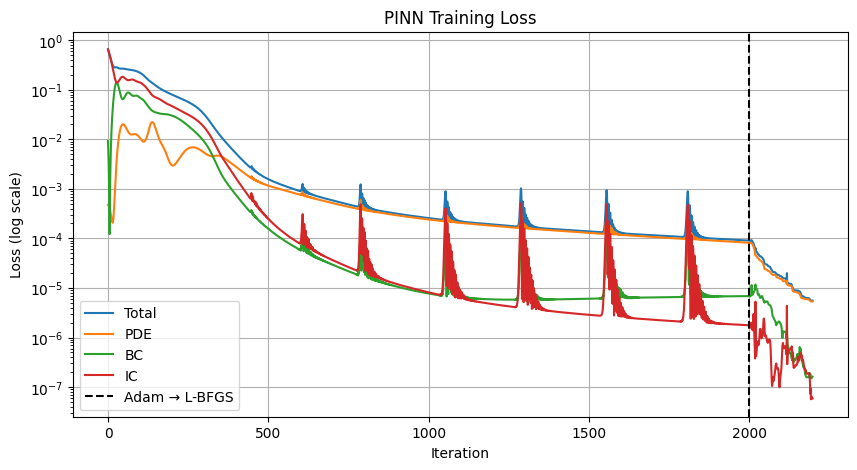

In [5]:
model = pinn_architecture()

alpha = 0.4

optimizer = torch.optim.Adam(model.parameters(), lr = 1e-3)

x_f, t_f, x_bc, t_bc, x_ic, t_ic = sample_points(10000, 200, 200)

N_iters = 2000

history_total = []
history_pde = []
history_bc = []
history_ic = []

pinn_train_start = time.time()

for i in range(1, N_iters + 1):
    optimizer.zero_grad()
    
    total_loss, pde_loss, bc_loss, ic_loss = compute_loss(model, alpha, x_f, t_f, x_bc, t_bc, x_ic, t_ic)
    
    total_loss.backward()
    
    optimizer.step()
    
    history_total.append(total_loss.item())
    history_pde.append(pde_loss.item())
    history_bc.append(bc_loss.item())
    history_ic.append(ic_loss.item())
    
    if i % 200 == 0:
        print(f"Iter {i} | Total: {total_loss.item():.4e} | PDE: {pde_loss.item():.4e} | BC: {bc_loss.item():.4e} | IC: {ic_loss.item():.4e}")

adam_iters = len(history_total)

optimizer_lbfgs = torch.optim.LBFGS(model.parameters(), lr=1.0, max_iter=500)
lbfgs_iter = [0]

def closure():
    optimizer_lbfgs.zero_grad()
    total_loss, pde_loss, bc_loss, ic_loss = compute_loss(model, alpha, x_f, t_f, x_bc, t_bc, x_ic, t_ic)
    total_loss.backward()
    
    history_total.append(total_loss.item())
    history_pde.append(pde_loss.item())
    history_bc.append(bc_loss.item())
    history_ic.append(ic_loss.item())
    
    lbfgs_iter[0] += 1
    
    if lbfgs_iter[0] % 10 == 0:
        print(f"L-BFGS Iter {lbfgs_iter[0]} | Total: {total_loss.item():.4e} | PDE: {pde_loss.item():.4e} | BC: {bc_loss.item():.4e} | IC: {ic_loss.item():.4e}")

    return total_loss

optimizer_lbfgs.step(closure)

pinn_train_time = time.time() - pinn_train_start
print(f"\nPINN total training time: {pinn_train_time:.2f}s")
print(f"Adam iterations: {adam_iters} | L-BFGS closure calls: {lbfgs_iter[0]}")

plt.figure(figsize=(10, 5))
plt.semilogy(history_total, label='Total')
plt.semilogy(history_pde, label='PDE')
plt.semilogy(history_bc, label='BC')
plt.semilogy(history_ic, label='IC')
plt.axvline(x=adam_iters, color='black', linestyle='--', label='Adam → L-BFGS')
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.title('PINN Training Loss')
plt.legend()
plt.grid(True)
plt.show()

PINN inference time : 0.1424s
PINN rel L2 error   : 7.3322e-04
PINN L-inf error    : 1.4673e-03


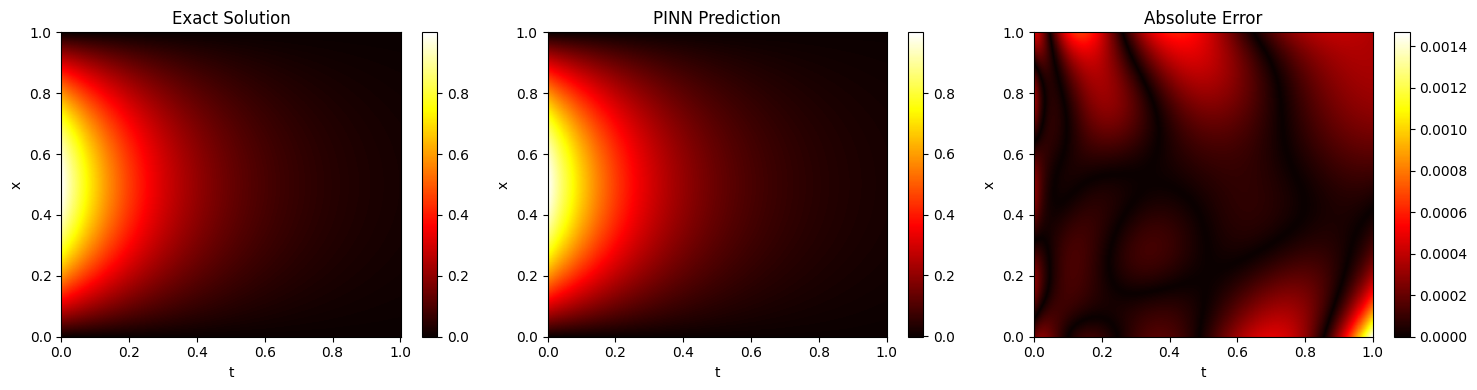

In [6]:
x = torch.linspace(0, 1, 1000)
t = torch.linspace(0, 1, 1000)

X, T = torch.meshgrid(x, t, indexing='ij')

x_flat = X.reshape(-1, 1)
t_flat = T.reshape(-1, 1)

pinn_infer_start = time.time()
with torch.no_grad():
    u_pred = model(x_flat, t_flat)
pinn_infer_time = time.time() - pinn_infer_start

u_exact = torch.sin(torch.pi*x_flat)*torch.exp(-alpha*(torch.pi**2)*t_flat)

error = torch.norm(u_pred - u_exact) / torch.norm(u_exact)
linf_error_pinn = torch.max(torch.abs(u_pred - u_exact)).item()

print(f"PINN inference time : {pinn_infer_time:.4f}s")
print(f"PINN rel L2 error   : {error.item():.4e}")
print(f"PINN L-inf error    : {linf_error_pinn:.4e}")

u_pred_grid = u_pred.reshape(1000, 1000)
u_exact_grid = u_exact.reshape(1000, 1000)
u_abs_error = torch.abs(u_pred - u_exact).reshape(1000, 1000)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1 - exact solution
im1 = axes[0].pcolormesh(T.numpy(), X.numpy(), u_exact_grid.numpy(), cmap='hot')
axes[0].set_title('Exact Solution')
axes[0].set_xlabel('t')
axes[0].set_ylabel('x')
plt.colorbar(im1, ax=axes[0])

# Plot 2 - PINN prediction
im2 = axes[1].pcolormesh(T.numpy(), X.numpy(), u_pred_grid.numpy(), cmap='hot')
axes[1].set_title('PINN Prediction')
axes[1].set_xlabel('t')
axes[1].set_ylabel('x')
plt.colorbar(im2, ax=axes[1])

# Plot 3 - absolute error
im3 = axes[2].pcolormesh(T.numpy(), X.numpy(), u_abs_error.numpy(), cmap='hot')
axes[2].set_title('Absolute Error')
axes[2].set_xlabel('t')
axes[2].set_ylabel('x')
plt.colorbar(im3, ax=axes[2])

plt.tight_layout()
plt.show()

In [7]:
def fd_solver( N_x, N_t, alpha = 0.4, T = 1.0, L = 1):
    dx = L / (N_x - 1)
    dt = T / (N_t - 1)
    
    r = alpha * dt / (dx **2)
    
    x = np.linspace(0, 1, N_x)
    t = np.linspace(0, 1, N_t)
    
    u = np.zeros((N_x, N_t))
    
    u[:, 0] = np.sin(np.pi * x)
    
    #setup tridiagonal matrix
    main_diag = (1 + r) * np.ones(N_x - 2) # -2 here because endpoints are zeros
    off_diag = (-r/2) * np.ones(N_x - 3)
    
    A = np.diag(main_diag) + np.diag(off_diag, 1) + np.diag(off_diag, -1)
    
    for  n in range(N_t - 1):
        b = (r/2) * u[:-2, n] + (1-r) * u[1:-1, n] + (r/2) * u[2:, n]
        u_new = np.linalg.solve(A, b)
        u[1:-1, n+1] = u_new
    
    X, T = np.meshgrid(x, t, indexing='ij')
    u_exact = np.sin(np.pi * X) * np.exp(-alpha * (np.pi**2) * T)

    
    error = np.linalg.norm(u - u_exact) / np.linalg.norm(u_exact)

    return x, t, u, error

conv_errors = []
N_values = [50, 100, 200, 400, 800]

for nx in N_values:
    x_c, t_c, u_c, conv_error = fd_solver(nx, nx * 2)
    conv_errors.append(conv_error)

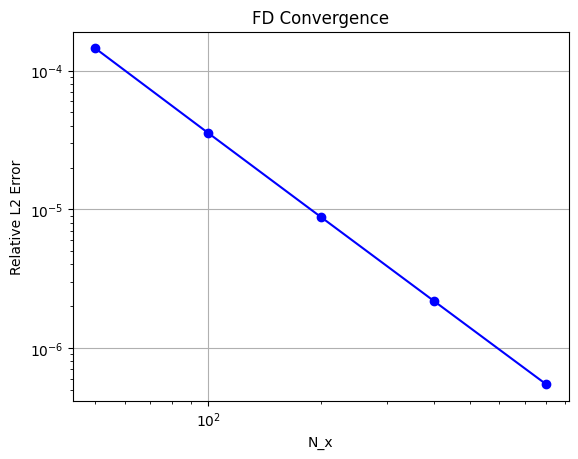

In [8]:
plt.figure()
plt.loglog(N_values, conv_errors, 'bo-', label='CN Error')
plt.xlabel('N_x')
plt.ylabel('Relative L2 Error')
plt.title('FD Convergence')
plt.grid(True)
plt.show()

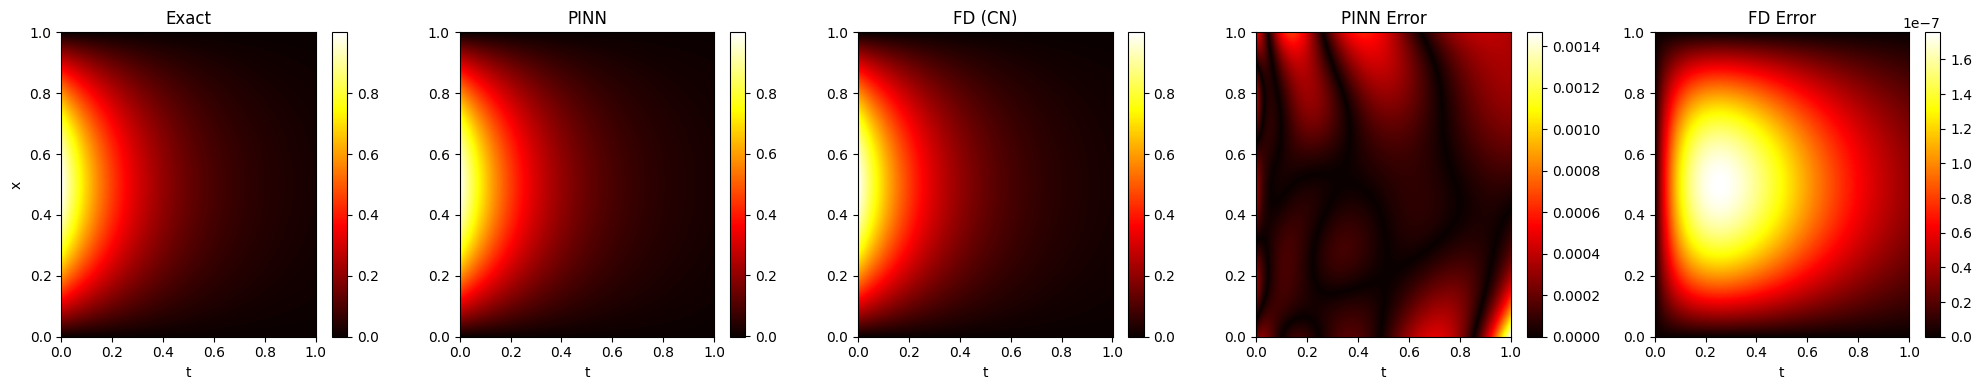

                                  PINN      FD (CN)
--------------------------------------------------
Training time (s)                29.51          N/A
Inference time (s)              0.1424      15.4249
Rel L2 error                7.3322e-04   3.3437e-07
L-inf error                 1.4673e-03   1.7558e-07


In [9]:
fd_start = time.time()
x_fd, t_fd, u_fd, error_fd = fd_solver(1000, 1000)
fd_time = time.time() - fd_start

X_fd, T_fd = np.meshgrid(x_fd, t_fd, indexing='ij')
u_exact_fd = np.sin(np.pi * X_fd) * np.exp(-0.4 * (np.pi**2) * T_fd)
linf_error_fd = np.max(np.abs(u_fd - u_exact_fd))

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Exact
im1 = axes[0].pcolormesh(T.numpy(), X.numpy(), u_exact_grid.numpy(), cmap='hot')
axes[0].set_title('Exact')
axes[0].set_xlabel('t')
axes[0].set_ylabel('x')
plt.colorbar(im1, ax=axes[0])

# PINN prediction
im2 = axes[1].pcolormesh(T.numpy(), X.numpy(), u_pred_grid.numpy(), cmap='hot')
axes[1].set_title('PINN')
axes[1].set_xlabel('t')
plt.colorbar(im2, ax=axes[1])

# FD prediction
im3 = axes[2].pcolormesh(T.numpy(), X.numpy(), u_fd, cmap='hot')
axes[2].set_title('FD (CN)')
axes[2].set_xlabel('t')
plt.colorbar(im3, ax=axes[2])

# PINN error
im4 = axes[3].pcolormesh(T.numpy(), X.numpy(), u_abs_error.numpy(), cmap='hot')
axes[3].set_title('PINN Error')
axes[3].set_xlabel('t')
plt.colorbar(im4, ax=axes[3])

# FD error
im5 = axes[4].pcolormesh(T.numpy(), X.numpy(), np.abs(u_fd - u_exact_fd), cmap='hot')
axes[4].set_title('FD Error')
axes[4].set_xlabel('t')
plt.colorbar(im5, ax=axes[4])

plt.tight_layout()
plt.show()

print(f"{'':25} {'PINN':>12} {'FD (CN)':>12}")
print(f"{'-'*50}")
print(f"{'Training time (s)':25} {pinn_train_time:>12.2f} {'N/A':>12}")
print(f"{'Inference time (s)':25} {pinn_infer_time:>12.4f} {fd_time:>12.4f}")
print(f"{'Rel L2 error':25} {error.item():>12.4e} {error_fd:>12.4e}")
print(f"{'L-inf error':25} {linf_error_pinn:>12.4e} {linf_error_fd:>12.4e}")

In [30]:
config = {
    "N_f": 10000,
    "N_bc": 200,
    "N_ic": 200,
    "N_obs": 10,        # sparse observations
    "noise_std": 0.05,   # noise level — easy to sweep later
    "alpha_init": 0.1,   # initial guess for alpha
    "true_alpha": 0.4,
    "adam_lr": 1e-3,
    "adam_iters": 5000,
    "lbfgs_iters": 500,
    "hidden_size": 20,
    "n_layers": 4,
}

In [31]:
def generate_noisy_data(config):
    x_obs = torch.rand(config["N_obs"], 1)
    t_obs = torch.rand(config["N_obs"], 1)
    
    u_exact = torch.sin(torch.pi * x_obs) * torch.exp(-config["true_alpha"] * torch.pi**2 * t_obs)
    
    noise = torch.randn(config["N_obs"], 1) * config["noise_std"]
    
    u_obs = u_exact + noise
    
    return x_obs, t_obs, u_obs

In [32]:
def compute_loss_inverse(model, alpha, x_f, t_f, x_bc, t_bc, x_ic, t_ic, x_obs, t_obs, u_obs):
    x_f.requires_grad_(True)
    t_f.requires_grad_(True)
    
    #get u values from model
    u_f = model(x_f,t_f)
    
    #compute x derivatives using autograd
    u_x = torch.autograd.grad(u_f, x_f, grad_outputs = torch.ones_like(u_f), create_graph = True)[0]
    u_xx = torch.autograd.grad(u_x, x_f, grad_outputs = torch.ones_like(u_x), create_graph = True)[0]
    
    #compute t derivative the same way
    u_t = torch.autograd.grad(u_f, t_f, grad_outputs = torch.ones_like(u_f), create_graph = True)[0]
    
    #pde loss from pde residual
    pde_residual = u_t - alpha * u_xx
    pde_loss = torch.mean(pde_residual**2)
    
    #boundary condition loss 
    u_bc = model(x_bc, t_bc)
    bc_loss = torch.mean(u_bc**2)
    
    #initial conditions loss from start u(x,0) = sin(pi*x)
    u_ic = model(x_ic, t_ic)
    true_ic = torch.sin(torch.pi * x_ic)
    ic_loss = torch.mean((u_ic - true_ic)**2)
    
    u_pred_obs = model(x_obs, t_obs)
    data_loss = torch.mean((u_pred_obs - u_obs)**2)
    
    #add the 4 for total loss
    total_loss = pde_loss + bc_loss + ic_loss + data_loss
    
    return total_loss, pde_loss, bc_loss, ic_loss, data_loss

Iter 200 | Total: 7.1292e-02 | PDE: 5.5114e-03 | BC: 1.7088e-02 | IC: 3.2605e-02 | Alpha: 2.6908e-01
Iter 400 | Total: 8.5702e-03 | PDE: 2.3643e-03 | BC: 4.9767e-04 | IC: 5.9308e-04 | Alpha: 2.8310e-01
Iter 600 | Total: 3.9354e-03 | PDE: 1.5626e-03 | BC: 1.4827e-04 | IC: 2.6796e-04 | Alpha: 3.5066e-01
Iter 800 | Total: 2.5598e-03 | PDE: 9.6428e-04 | BC: 1.3316e-04 | IC: 7.2166e-05 | Alpha: 3.7950e-01
Iter 1000 | Total: 1.9803e-03 | PDE: 5.9539e-04 | BC: 1.1821e-04 | IC: 3.9229e-05 | Alpha: 3.9425e-01
Iter 1200 | Total: 1.5926e-03 | PDE: 3.2701e-04 | BC: 9.9299e-05 | IC: 1.5004e-05 | Alpha: 4.0447e-01
Iter 1400 | Total: 1.3719e-03 | PDE: 1.8715e-04 | BC: 7.8774e-05 | IC: 9.2616e-06 | Alpha: 4.1227e-01
Iter 1600 | Total: 1.2862e-03 | PDE: 1.4197e-04 | BC: 7.3776e-05 | IC: 9.8696e-06 | Alpha: 4.1769e-01
Iter 1800 | Total: 1.2484e-03 | PDE: 1.2471e-04 | BC: 7.7089e-05 | IC: 8.9348e-06 | Alpha: 4.2108e-01
Iter 2000 | Total: 1.2258e-03 | PDE: 1.1328e-04 | BC: 8.0682e-05 | IC: 9.8023e-06 | Al

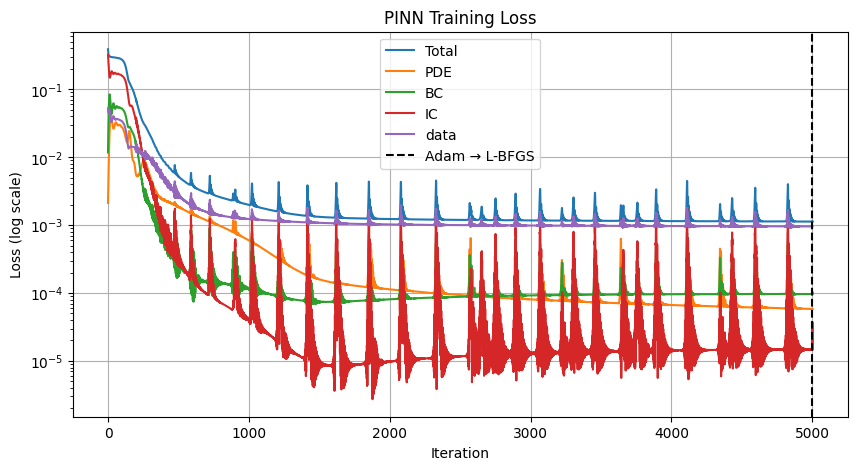

In [34]:
model = pinn_architecture()

alpha = nn.Parameter(torch.tensor(config["alpha_init"]))

optimizer = torch.optim.Adam(list(model.parameters()) + [alpha], lr = config["adam_lr"])

x_f, t_f, x_bc, t_bc, x_ic, t_ic = sample_points(config["N_f"], config["N_bc"], config["N_ic"])

N_iters = config["adam_iters"]

history_total = []
history_pde = []
history_bc = []
history_ic = []
history_data = []
history_alpha = []

inverse_train_start = time.time()

x_obs, t_obs, u_obs = generate_noisy_data(config)

for i in range(1, N_iters + 1):
    optimizer.zero_grad()
    
    total_loss, pde_loss, bc_loss, ic_loss, data_loss = compute_loss_inverse(model, alpha, x_f, t_f, x_bc, t_bc, x_ic, t_ic, x_obs, t_obs, u_obs)
    
    total_loss.backward()
    
    optimizer.step()
    
    history_total.append(total_loss.item())
    history_pde.append(pde_loss.item())
    history_bc.append(bc_loss.item())
    history_ic.append(ic_loss.item())
    history_data.append(data_loss.item())
    history_alpha.append(alpha.item())
    
    if i % 200 == 0:
        print(f"Iter {i} | Total: {total_loss.item():.4e} | PDE: {pde_loss.item():.4e} | BC: {bc_loss.item():.4e} | IC: {ic_loss.item():.4e} | Alpha: {alpha.item():.4e}")

adam_iters = len(history_total)

optimizer_lbfgs = torch.optim.LBFGS(list(model.parameters()) + [alpha], lr=1.0, max_iter=config["lbfgs_iters"])
lbfgs_iter = [0]

def closure():
    optimizer_lbfgs.zero_grad()
    total_loss, pde_loss, bc_loss, ic_loss, data_loss = compute_loss_inverse(model, alpha, x_f, t_f, x_bc, t_bc, x_ic, t_ic, x_obs, t_obs, u_obs)
    total_loss.backward()
    
    history_total.append(total_loss.item())
    history_pde.append(pde_loss.item())
    history_bc.append(bc_loss.item())
    history_ic.append(ic_loss.item())
    history_data.append(data_loss.item())
    history_alpha.append(alpha.item())
    
    lbfgs_iter[0] += 1
    
    if lbfgs_iter[0] % 10 == 0:
        print(f"L-BFGS Iter {lbfgs_iter[0]} | Total: {total_loss.item():.4e} | PDE: {pde_loss.item():.4e} | BC: {bc_loss.item():.4e} | IC: {ic_loss.item():.4e}| Alpha: {alpha.item():.4e}")


    return total_loss

optimizer_lbfgs.step(closure)

inverse_train_time = time.time() - inverse_train_start
print(f"\nPINN total training time: {inverse_train_time:.2f}s")
print(f"Adam iterations: {adam_iters} | L-BFGS closure calls: {lbfgs_iter[0]}")

plt.figure(figsize=(10, 5))
plt.semilogy(history_total, label='Total')
plt.semilogy(history_pde, label='PDE')
plt.semilogy(history_bc, label='BC')
plt.semilogy(history_ic, label='IC')
plt.semilogy(history_data, label='data')
plt.axvline(x=adam_iters, color='black', linestyle='--', label='Adam → L-BFGS')
plt.xlabel('Iteration')
plt.ylabel('Loss (log scale)')
plt.title('PINN Training Loss')
plt.legend()
plt.grid(True)
plt.show()

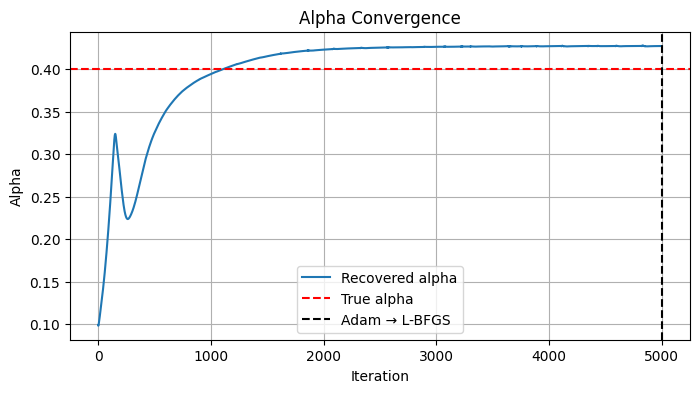

In [35]:
plt.figure(figsize=(8, 4))
plt.plot(history_alpha, label='Recovered alpha')
plt.axhline(y=config["true_alpha"], color='r', linestyle='--', label='True alpha')
plt.axvline(x=adam_iters, color='black', linestyle='--', label='Adam → L-BFGS')
plt.xlabel('Iteration')
plt.ylabel('Alpha')
plt.title('Alpha Convergence')
plt.legend()
plt.grid(True)
plt.show()
